In [24]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn textblob spacy wordcloud plotly gensim bertopic
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
#STEP 2: Load Dataset
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets.csv')

print(df.head())
print(df.columns)

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [6]:
#STEP 3: Text Cleaning
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string values like NaN
        return ""
    text = text.lower() # Lowercasing
    text = ''.join([char for char in text if char not in string.punctuation]) # Remove punctuation
    tokens = text.split() # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

df['Cleaned_Description'] = df['Ticket Description'].apply(preprocess_text)
display(df[['Ticket Description', 'Cleaned_Description']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Ticket Description,Cleaned_Description
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


In [7]:
#STEP 4: Sentiment Analysis
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['Cleaned_Description'].apply(get_sentiment)

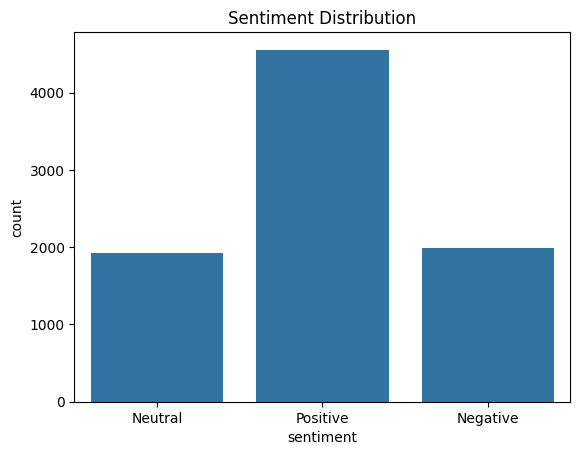

In [8]:
#STEP 5: Sentiment Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

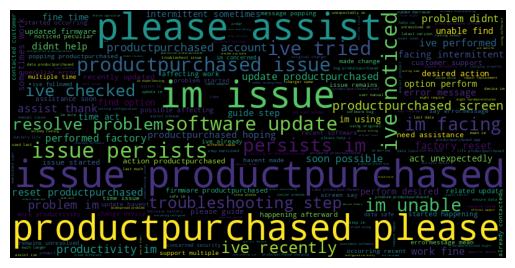

In [9]:
# STEP 6: WordCloud (Customer Pain Points)
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Cleaned_Description'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [10]:
#STEP 7: Topic Modeling (LDA)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
X = vectorizer.fit_transform(df['Cleaned_Description'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

def print_topics(model, feature_names):
    for i, topic in enumerate(model.components_):
        print(f"Topic {i}:")
        print([feature_names[i] for i in topic.argsort()[-10:]])

print_topics(lda, vectorizer.get_feature_names_out())

Topic 0:
['work', 'find', 'need', 'might', 'option', 'product', 'account', 'assist', 'please', 'im']
Topic 1:
['change', 'software', 'update', 'made', 'problem', 'device', 'ive', 'assist', 'please', 'im']
Topic 2:
['message', 'data', 'software', 'error', 'update', 'noticed', 'assist', 'im', 'please', 'ive']
Topic 3:
['help', 'customer', 'didnt', 'resolve', 'problem', 'assist', 'support', 'im', 'please', 'ive']
Topic 4:
['network', 'problem', 'facing', 'persists', 'ive', 'tried', 'assist', 'fine', 'please', 'im']


In [11]:
#STEP 8: Urgency Detection (Rule-based + ML)
urgent_keywords = ['urgent', 'immediately', 'asap', 'critical', 'failure']

def detect_urgency(text):
    return any(word in text for word in urgent_keywords)

df['urgent'] = df['Cleaned_Description'].apply(detect_urgency)

In [12]:
#STEP 9: Actionable Insights
# Top negative issues
neg = df[df['sentiment'] == 'Negative']
top_issues = neg['Cleaned_Description'].value_counts().head(10)
print(top_issues)


Cleaned_Description
im issue productpurchased please assist ive noticed peculiar error message popping productpurchased screen say errormessage mean                                                                                                                                 26
im issue productpurchased please assist im unable find option perform desired action productpurchased could please guide step                                                                                                                                    22
im issue productpurchased please assist rely heavily productpurchased daily task issue hindering productivity                                                                                                                                                    15
im unable access productpurchased account keep displaying invalid credential error even though im using correct login information regain access account im unable find option perform desired action pro

# Business Insights

In [13]:
#  Use BERT embeddings
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df['Cleaned_Description'].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
#Clustering (Customer Issue Groups)
from sklearn.cluster import KMeans

# Better initialization
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(embeddings)

In [21]:
import numpy as np

def get_cluster_keywords(texts, labels, n_clusters=5):
    cluster_keywords = {}
    for i in range(n_clusters):
        cluster_texts = np.array(texts)[labels == i]
        combined = " ".join(cluster_texts[:50])
        cluster_keywords[i] = combined[:200]
    return cluster_keywords

cluster_info = get_cluster_keywords(
    df["Cleaned_Description"].values,
    df["cluster"].values
)

print("\nCluster Summaries:")
for k, v in cluster_info.items():
    print(f"Cluster {k}: {v}")


Cluster Summaries:
Cluster 0: productpurchased making strange noise functioning properly suspect might hardware issue please help please send request dav issue im facing intermittent sometimes work fine time act unexpectedly im is
Cluster 1: im issue productpurchased please assist acknowledgement thanks dan tip purchase new product store local retailer also provide im concerned security productpurchased would like ensure data safe ive not
Cluster 2: im unable access productpurchased account keep displaying invalid credential error even though im using correct login information regain access account solution 1 im unable find option perform desired
Cluster 3: im issue productpurchased please assist billing zip code 71701 appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persist
Cluster 4: ive recently set productpurchased fails connect available network step take troubleshoot issue cant find productip field 

In [25]:
# ================= BERTopic (ADVANCED) =================
from bertopic import BERTopic

print("\nRunning BERTopic...")

topic_model = BERTopic(min_topic_size=10, verbose=True)
topics, probs = topic_model.fit_transform(df['Cleaned_Description'].tolist(), embeddings)

df['topic'] = topics

print("\nTop Topics:")
print(topic_model.get_topic_info().head())

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2026-04-02 05:44:51,645 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Running BERTopic...


2026-04-02 05:45:39,535 - BERTopic - Dimensionality - Completed ✓
2026-04-02 05:45:39,537 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 05:45:39,861 - BERTopic - Cluster - Completed ✓
2026-04-02 05:45:39,868 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 05:45:40,137 - BERTopic - Representation - Completed ✓



Top Topics:
   Topic  Count                                       Name  \
0     -1    830  -1_affecting_productivity_assistance_soon   
1      0    339           0_occurring_recent_havent_change   
2      1    337               1_desired_find_guide_perform   
3      2    328       2_peculiar_popping_errormessage_mean   
4      3    325     3_afterward_firmware_happening_related   

                                      Representation  \
0  [affecting, productivity, assistance, soon, po...   
1  [occurring, recent, havent, change, made, star...   
2  [desired, find, guide, perform, action, option...   
3  [peculiar, popping, errormessage, mean, messag...   
4  [afterward, firmware, happening, related, upda...   

                                 Representative_Docs  
0  [im issue productpurchased please assist thank...  
1  [im issue productpurchased please assist probl...  
2  [im issue productpurchased please assist im un...  
3  [im issue productpurchased please assist ive n...  
4 

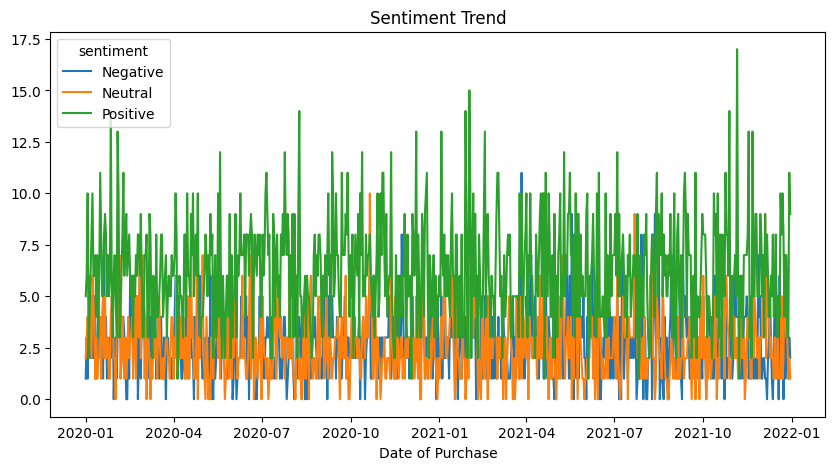

In [26]:
# ================= TIME SERIES =================
if 'Date of Purchase' in df.columns:
    df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')
    df = df.dropna(subset=['Date of Purchase'])

    trend = df.groupby([
        df['Date of Purchase'].dt.date,
        'sentiment'
    ]).size().unstack().fillna(0)

    trend.plot(figsize=(10,5), title="Sentiment Trend")
    plt.show()